# Laboratorio estructural digital — Semana 2

**Edificio LT2** · Grupo 7 — Pedro Castillo, Monserrat Cubillos, Eduardo Vergara

Este notebook corre el laboratorio completo de principio a fin:

```
planos DXF → geometría → áreas tributarias → OpenSees → verificaciones → JSON → Unity
```

**Regla de oro del proyecto:** OpenSees *calcula*, el JSON es la *fuente de verdad*,
Unity solo *muestra*. En este notebook no se calcula nada estructural que no venga
de OpenSees.

> **Qué cambió.** La estructura era el Edificio de Ingeniería idealizado como una
> **grilla regular** (8 ejes × 6 ejes × 9 niveles, una columna en cada cruce). Ahora
> es el **LT2**, armado entero desde sus planos de cálculo `2024_22`, y no es una
> grilla: 8 pilares y 9 muros sin simetría, vigas que se cruzan entre ellas, una caja
> de ascensores, y una planta que no es un rectángulo lleno. El código del
> laboratorio es el mismo; lo que cambió es de dónde sale la estructura. Los
> detalles, en el encabezado de `src/modelo_edificio.py`.

Correr con `Kernel → Restart & Run All`, o celda por celda para la defensa.

---
## 0. Preparación

Se agrega `src/` al path para poder importar los módulos del proyecto.

In [1]:
import os
import sys


def raiz_del_proyecto(marca='src/modelo_edificio.py'):
    """
    Busca la raiz del repo subiendo desde el directorio actual.

    No se usa os.path.abspath('') a secas porque eso depende de DONDE se
    lanzo Jupyter: si se abre desde la carpeta de arriba, los imports y
    las rutas de datos fallan con un error poco claro.
    """
    d = os.path.abspath('')
    for _ in range(5):
        if os.path.exists(os.path.join(d, marca)):
            return d
        padre = os.path.dirname(d)
        if padre == d:
            break
        d = padre
    raise RuntimeError(
        'No encuentro la raiz del proyecto (falta ' + marca + '). '
        'Abre el notebook desde la carpeta P1L2_Grupo_7.')


RAIZ = raiz_del_proyecto()
os.chdir(RAIZ)                      # para que %run y las rutas relativas peguen
sys.path.insert(0, os.path.join(RAIZ, 'src'))

import openseespy.opensees as ops
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as PolyPatch

import areas_tributarias as at
import modelo_edificio as M

print('OpenSees  ', ops.version())
print('matplotlib', matplotlib.__version__)
print('proyecto  ', RAIZ)
print('modelo LT2', M.LT2_SRC)

OpenSees   3.8.0
matplotlib 3.11.1
proyecto   C:\Users\Administrador\OneDrive\Escritorio\UANDES\202602\Metodos computacionales\P1\P1L2_Grupo_7
modelo LT2 C:\Users\Administrador\OneDrive\Escritorio\UANDES\202602\Metodos computacionales\P1\A1P1.0_Grupo_7\src


---
## 1. Geometría del edificio

Todo sale de los planos de cálculo `2024_22` del LT2, leídos por script — nada
escrito a mano. Tres plantas (`100` fundaciones, `101` cielo 1° subt. a cielo piso
3°, `102` cielo 4° piso) y seis elevaciones.

Los **ejes** salen de las burbujas de la capa `RLE-EJE`, con el nombre que les puso
el calculista. Ojo: en la grilla vieja los ejes *definían* la estructura; acá son
referencia — **no hay una columna en cada cruce**.

Los **niveles** salen de las seis elevaciones: una cota es un piso del edificio sólo
si las seis coinciden en ella. Una que aparece en una sola es una cota local (un
antepecho, una losa de sala de máquinas).

In [2]:
print('Ejes X (%d):' % M.nX)
for n, c in M.EJES['X']:
    print('   %-4s %8.3f' % (n, c))
print('Ejes Y (%d):' % M.nY)
for n, c in M.EJES['Y']:
    print('   %-4s %8.3f' % (n, c))
print()
print('Niveles (%d):' % M.nNiveles, M.NIVELES_Z)
print('Altura       %.2f m   (%.2f m entre pisos, constante)'
      % (M.ALTURA, M.NIVELES_Z[2] - M.NIVELES_Z[1]))
print('Area de losa %.2f m2 por piso   (suma de los panos detectados)' % M.AREA_PLANTA)
print('Nodos/piso   %d   (NO es nX*nY: la planta no es una grilla)' % M.NODOS_POR_PISO)
print()
print("Hormigon     f'c = %.0f MPa   Ec = %.0f MPa   gamma = %.0f kN/m3"
      % (M.FPC, M.Ec / 1000, M.GAMMA))
print('J pilar      %.6e m4  (Saint-Venant, no min(Iy,Iz)*0.3)'
      % M.J_rectangular(0.70, 0.70))

Ejes X (10):
   A'     10.965
   A      14.745
   B      22.245
   C      32.236
   B'     35.415
   C'     39.787
   D      42.236
   E1     42.407
   D'     42.919
   E'     43.747
Ejes Y (8):
   3      11.047
   2A'    15.312
   2      18.297
   1A'    22.932
   1'     23.992
   1      27.197
   8A     33.617
   8B     37.917

Niveles (6): [-7.97, -4.01, -0.05, 3.91, 7.87, 11.83]
Altura       19.80 m   (3.96 m entre pisos, constante)
Area de losa 496.87 m2 por piso   (suma de los panos detectados)
Nodos/piso   46   (NO es nX*nY: la planta no es una grilla)

Hormigon     f'c = 35 MPa   Ec = 27806 MPa   gamma = 25 kN/m3
J pilar      3.381408e-02 m4  (Saint-Venant, no min(Iy,Iz)*0.3)


### 1.1 Muros, pilares y vigas leídos del plano

Un muro se dibuja como sus **dos caras** (dos segmentos paralelos), así que el
ingestor las empareja para obtener eje y espesor. El resultado se contrasta contra
los rótulos `M.H.A. e=…`, que son otra fuente del mismo plano: 9 muros, 9 rótulos,
y los espesores calzan uno a uno.

En las vigas la verificación cruzada es análoga: el **ancho** se mide del dibujo y
el **alto** se lee del rótulo (`V. 60/80` = 60 de ancho × 80 de alto).

In [3]:
muros = M.cargar_muros()
print('Muros extraidos del plano: %d\n' % len(muros))
print('%-4s%8s%8s%8s%8s%8s%7s'
      % ('id', 'x1', 'y1', 'x2', 'y2', 'largo', 'esp'))
print('-' * 51)
for m in muros:
    print('%-4d%8.2f%8.2f%8.2f%8.2f%8.2f%7.2f'
          % (m['id'], m['x1'], m['y1'], m['x2'], m['y2'], m['largo'], m['espesor']))

print('\nPilares: %d' % len(M.cargar_pilares()))
for c in M.cargar_pilares():
    print('   (%7.2f, %7.2f)  %.2f x %.2f   rotulo: %s'
          % (c['x'], c['y'], c['b'], c['h'], c.get('etiqueta')))

print('\nVigas de la planta tipo: %d' % len(M.cargar_vigas()))
for v in M.cargar_vigas():
    print('   (%6.2f,%6.2f)-(%6.2f,%6.2f)  L=%5.2f  %.2f/%.2f   %s'
          % (v['x1'], v['y1'], v['x2'], v['y2'], v['largo'],
             v['ancho'], v['alto'], v.get('etiqueta')))

Muros extraidos del plano: 9

id        x1      y1      x2      y2   largo    esp
---------------------------------------------------
1      42.58   10.58   42.58   18.53    7.95   0.25
2      11.30   25.25   11.30   28.17    2.92   0.60
3      11.30    9.84   11.30   12.75    2.92   0.60
4      39.93   20.93   39.93   23.75    2.82   0.25
5      42.58   20.93   42.58   23.75    2.82   0.25
6      42.58   24.05   42.58   26.73    2.68   0.25
7      40.06   23.90   42.45   23.90    2.40   0.30
8      11.50   10.93   12.95   10.93    1.45   0.30
9      11.50   27.08   12.95   27.08    1.45   0.30

Pilares: 8
   (  22.35,   10.93)  0.70 x 0.70   rotulo: 70x70
   (  32.35,   10.93)  0.70 x 0.70   rotulo: 70x70
   (  14.85,   18.18)  0.70 x 0.70   rotulo: 70x70
   (  22.35,   18.18)  0.70 x 0.70   rotulo: 70x70
   (  32.35,   18.18)  0.70 x 0.70   rotulo: 70x70
   (  22.35,   27.08)  0.70 x 0.70   rotulo: 70x70
   (  32.35,   27.08)  0.70 x 0.70   rotulo: 70x70
   (  42.35,   27.08)  0.70 x

---
## 2. Áreas tributarias (el corazón del Lab)

La losa **no** se modela con elementos finitos. Su carga se transfiere a las vigas
trazando las **bisectrices a 45°** desde las esquinas de cada paño:

| caso | forma | área |
|---|---|---|
| `b ≤ a` (viga larga) | trapecio | `b(2a−b)/4` |
| `b > a` (viga corta) | triángulo | `a²/4` |

**La diferencia con la grilla.** Allá los paños venían dados: el rectángulo entre
cuatro ejes consecutivos. Acá la planta es irregular y **los paños hay que
encontrarlos**: son las caras del grafo plano que forman las vigas y los muros de
cada piso.

Y trazar bisectrices es la construcción de dibujo; lo que *significa* es que cada
punto de losa carga al lado que tiene **más cerca**. Escrito así se calcula: la
región de un lado es el paño recortado por un semiplano por cada otro lado
(`dist(x, lado i) ≤ dist(x, lado j)`). En un rectángulo salen exactamente el
trapecio y el triángulo de las fórmulas de arriba — y eso se verifica.

In [4]:
trib = M.tributarias_por_viga(nivel=M.NIVEL_TIPO)

suma = sum(r['area'] for r in trib.values())
n_poli = sum(len(r['poligonos']) for r in trib.values())

print('Piso tipo (nivel %+.2f)' % M.NIVELES_Z[M.NIVEL_TIPO])
print('  barras con area tributaria : %d' % len(trib))
print('  poligonos                  : %d' % n_poli)
print('  suma de areas tributarias  : %.6f m2' % suma)
print('  area de los panos          : %.6f m2' % M.area_de_piso(M.NIVEL_TIPO))
print('  error                      : %.3e m2'
      % abs(suma - M.area_de_piso(M.NIVEL_TIPO)))
print()
aud = M.MODELO.aud_panos[M.NIVEL_TIPO]
print('  panos encontrados          : %d' % aud['caras_encontradas'])
print('  metodo de reparto          : %s' % aud['metodos'])
rot = aud['rotulos_de_losa']
print('  rotulos de losa del plano  : %d, repartidos en %d caras'
      % (rot['declarados'], rot['caras_con_rotulo']))
print('  caras SIN rotulo, descartadas: %d de %s m2  <- el hueco del ascensor'
      % (rot['caras_sin_rotulo_descartadas'], rot['areas_descartadas']))

Piso tipo (nivel -4.01)
  barras con area tributaria : 50
  poligonos                  : 80
  suma de areas tributarias  : 496.866640 m2
  area de los panos          : 496.867000 m2
  error                      : 3.602e-04 m2

  panos encontrados          : 17
  metodo de reparto          : {'bisectrices': 16, 'bisectrices_aprox': 1}
  rotulos de losa del plano  : 22, repartidos en 17 caras
  caras SIN rotulo, descartadas: 1 de [7.86] m2  <- el hueco del ascensor


### 2.1 Verlo: el reparto dibujado

Cada zona coloreada es la losa que descarga sobre **una** barra. Se ve de inmediato
que los paños alargados reparten muy distinto a los cuadrados, y que el hueco del
ascensor queda sin cargar a nadie — porque el plano no rotula losa ahí.

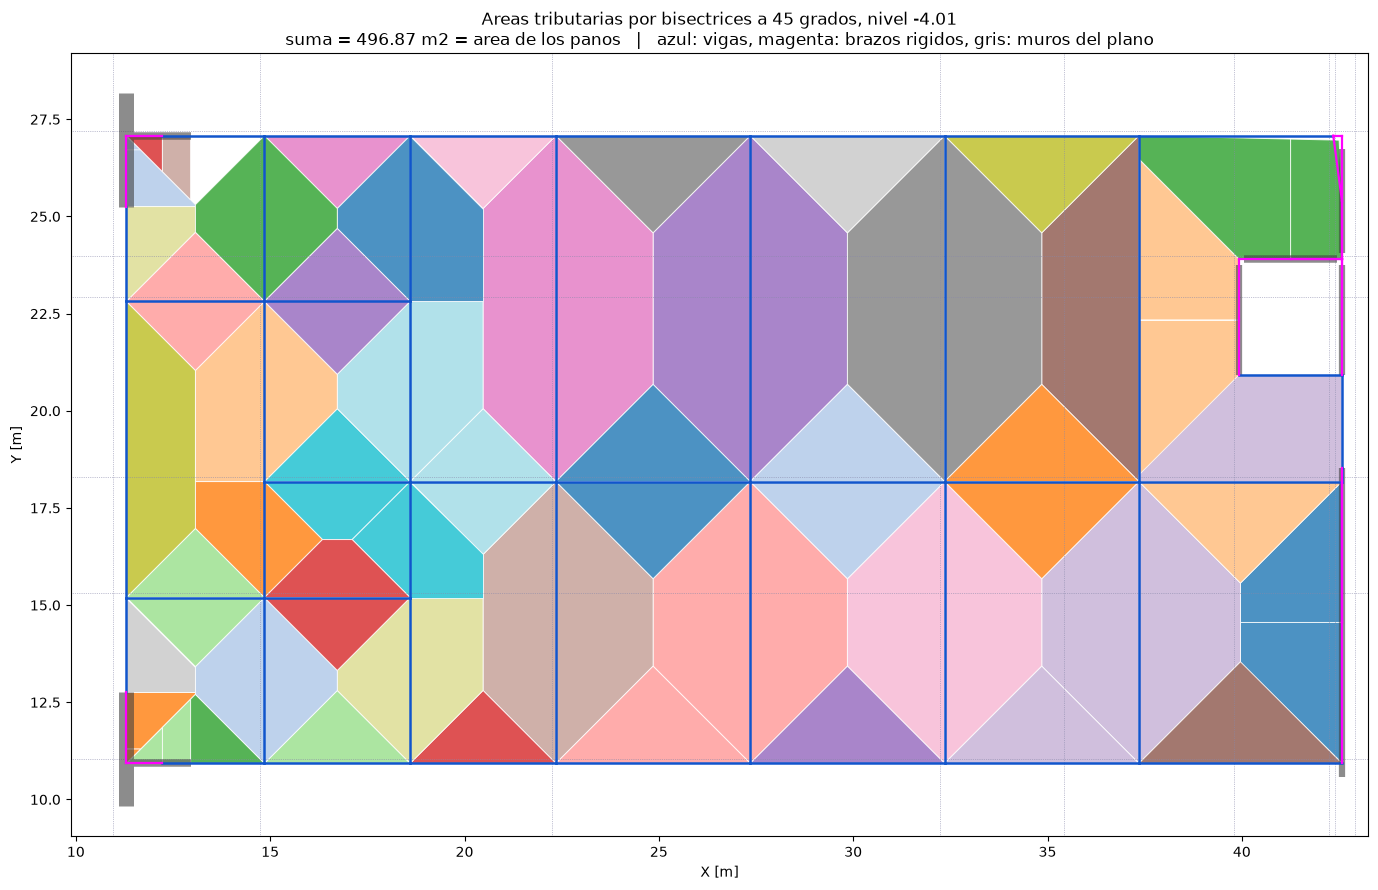

In [5]:
fig, ax = plt.subplots(figsize=(15, 9))

cmap = matplotlib.colormaps['tab20']
for k, (tag, reg) in enumerate(sorted(trib.items())):
    for poli in reg['poligonos']:
        ax.add_patch(PolyPatch(poli, closed=True, facecolor=cmap(k % 20),
                               edgecolor='white', linewidth=0.7, alpha=0.8))

# Las barras del piso, por encima
coords = M.TOPOLOGIA['coords']
z = M.NIVELES_Z[M.NIVEL_TIPO]
for grupo, color, lw in (('vigas_x', '#1155cc', 1.8), ('vigas_y', '#1155cc', 1.8),
                         ('brazos', 'magenta', 1.6)):
    for tag, n1, n2 in M.TOPOLOGIA[grupo]:
        a, b = coords[n1], coords[n2]
        if abs(a[2] - z) > 1e-6 or abs(b[2] - z) > 1e-6:
            continue
        ax.plot([a[0], b[0]], [a[1], b[1]], color=color, lw=lw, zorder=5)

# Los muros del plano, con su espesor real
for m in muros:
    ax.plot([m['x1'], m['x2']], [m['y1'], m['y2']], color='0.25',
            lw=m['espesor'] * 18, solid_capstyle='butt', alpha=0.6, zorder=4)

# La malla de ejes con nombre, de referencia
for n, c in M.EJES['X']:
    ax.axvline(c, color='#8888aa', lw=0.5, ls=':', zorder=1)
for n, c in M.EJES['Y']:
    if M.VENTANA['ymin'] - 2 < c < M.VENTANA['ymax'] + 2:
        ax.axhline(c, color='#8888aa', lw=0.5, ls=':', zorder=1)

ax.set_aspect('equal')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_xlim(M.VENTANA['xmin'] - 0.5, M.VENTANA['xmax'] + 0.5)
ax.set_ylim(M.VENTANA['ymin'] - 0.5, M.VENTANA['ymax'] + 0.5)
ax.set_title('Areas tributarias por bisectrices a 45 grados, nivel %+.2f\n'
             'suma = %.2f m2 = area de los panos   |   azul: vigas, '
             'magenta: brazos rigidos, gris: muros del plano' % (z, suma))
plt.tight_layout()
plt.show()

### 2.2 Por qué el reparto proporcional estaba mal

La versión de la Semana 1 daba la mitad de la carga a las vigas X y la mitad a las Y.
El mismo error de fondo aparece si se reparte **en proporción al largo** de cada
viga: las dos formas conservan la resultante, así que el **equilibrio global no las
distingue** — pero reparten mal.

En un paño cuadrado da lo mismo; en uno alargado, no.

In [6]:
Lx, Ly = 10.00, 3.34     # un pano real de este edificio

larga_45 = at.area_tributaria_viga(Lx, Ly)
corta_45 = at.area_tributaria_viga(Ly, Lx)
total = Lx * Ly
por_largo_larga = total / 2.0 * (Lx / (Lx + Ly))
por_largo_corta = total / 2.0 * (Ly / (Lx + Ly))
cincuenta = total / 4.0

print('Pano %.2f x %.2f m\n' % (Lx, Ly))
print('%-22s%12s%12s' % ('', 'viga larga', 'viga corta'))
print('-' * 46)
print('%-22s%12.3f%12.3f' % ('bisectrices 45', larga_45, corta_45))
print('%-22s%12.3f%12.3f' % ('por largo de viga', por_largo_larga, por_largo_corta))
print('%-22s%12.3f%12.3f' % ('reparto 50/50', cincuenta, cincuenta))
print()
print('El reparto por largo SOBRECARGA la viga corta un %.0f%%.'
      % ((por_largo_corta / corta_45 - 1) * 100))
print()
print('Los tres conservan el area total: %.3f = %.3f m2'
      % (2 * larga_45 + 2 * corta_45, total))
print('-> por eso el EQUILIBRIO GLOBAL NO DETECTA este error.')

Pano 10.00 x 3.34 m

                        viga larga  viga corta
----------------------------------------------
bisectrices 45              13.911       2.789
por largo de viga           12.519       4.181
reparto 50/50                8.350       8.350

El reparto por largo SOBRECARGA la viga corta un 50%.

Los tres conservan el area total: 33.400 = 33.400 m2
-> por eso el EQUILIBRIO GLOBAL NO DETECTA este error.


---
## 3. Construir el modelo y resolver

La carga de piso **no es un número escrito a mano**: sale del plano de cargas
(lámina 700), y no es uno solo — la lámina da un peso muerto adicional distinto
para las plantas tipo y para el cielo del 4° piso.

La carga se aplica **distribuida** sobre las vigas (`eleLoad -beamUniform`), con
`w = q·A_trib/L`. El peso propio de columnas y muros va como carga nodal (mitad a
cada extremo): es exacto y evita discutir en qué eje local cae la gravedad de una
columna.

In [7]:
topo = M.construir_modelo()

print('Columnas   %5d' % len(topo['columnas']))
print('Vigas X    %5d' % len(topo['vigas_x']))
print('Vigas Y    %5d' % len(topo['vigas_y']))
print('Muros      %5d   (columna ancha en su baricentro)' % len(topo['muros']))
print('Brazos     %5d   (rigidos, a muros y entre muros)' % len(topo['brazos']))
print('-' * 20)
print('Elementos  %5d' % topo['n_elementos'])
print('Nodos      %5d' % len(topo['coords']))
print('Apoyos     %5d   (empotrados en z = %+.2f)'
      % (len(topo['apoyos']), M.NIVELES_Z[0]))
print('Diafragmas %5d   (rigidDiaphragm, uno por piso)' % len(topo['diafragmas']))
print()
print('Secciones medidas del plano: %d' % len(M.SECCIONES))
for nombre in sorted(M.SECCIONES):
    s = M.SECCIONES[nombre]
    print('   %-14s A=%.4f  Iy=%.6f  Iz=%.6f  J=%.6f'
          % (nombre, s['A'], s['Iy'], s['Iz'], s['J']))

Columnas      40
Vigas X      125
Vigas Y      105
Muros         45   (columna ancha en su baricentro)
Brazos       115   (rigidos, a muros y entre muros)
--------------------
Elementos    430
Nodos        247
Apoyos        17   (empotrados en z = -7.97)
Diafragmas     5   (rigidDiaphragm, uno por piso)

Secciones medidas del plano: 12
   BRAZO          A=16.0000  Iy=21.333333  Iz=21.333333  J=36.053333
   M 0.25x2.68    A=0.6700  Iy=0.003490  Iz=0.401017  J=0.013138
   M 0.25x2.82    A=0.7050  Iy=0.003672  Iz=0.467303  J=0.013868
   M 0.25x7.95    A=1.9875  Iy=0.010352  Iz=10.467914  J=0.040586
   M 0.30x1.45    A=0.4350  Iy=0.003262  Iz=0.076216  J=0.011349
   M 0.30x2.40    A=0.7185  Iy=0.005389  Iz=0.343444  J=0.019854
   M 0.60x2.92    A=1.7520  Iy=0.052560  Iz=1.244854  J=0.183028
   P 0.70x0.70    A=0.4900  Iy=0.020008  Iz=0.020008  J=0.033814
   V 0.25x0.80    A=0.2000  Iy=0.001042  Iz=0.010667  J=0.003347
   V 0.30x0.80    A=0.2400  Iy=0.001800  Iz=0.012800  J=0.005502
   V 0.

In [8]:
M.nuevo_patron()
carga_G = M.aplicar_carga_gravitacional(topo)

ok = M.resolver()
print('Convergencia:', 'OK' if ok == 0 else 'FALLO')

sumRz = sum(ops.nodeReaction(n, 3) for n in topo['apoyos'])
uz_min = min(ops.nodeDisp(n, 3) for n in topo['coords'])

print('\nCarga aplicada G   %15.4f kN' % carga_G)
print('Suma reacciones Rz %15.4f kN' % sumRz)
print('Error equilibrio   %15.3e kN' % abs(carga_G - sumRz))
print('\nUZ maximo          %15.4f mm' % (uz_min * 1000))

Convergencia: OK

Carga aplicada G        34011.0591 kN
Suma reacciones Rz      34011.0591 kN
Error equilibrio         8.698e-08 kN

UZ maximo                  -6.7171 mm


---
## 4. Las 5 verificaciones del Lab

Se corre el script completo, el mismo que se usa fuera del notebook.

In [9]:
%run verificar_lab2.py

Estructura: edificio LT2, planos de calculo 2024_22
Modelo del LT2 tomado de: C:\Users\Administrador\OneDrive\Escritorio\UANDES\202602\Metodos computacionales\P1\A1P1.0_Grupo_7\src

 1. CARGA TOTAL DE LOSA POR PISO
  losa e = 0.15 m  ->  peso propio 25 x 0.15 = 3.750 kN/m2
  plantas tipo   q_G = 3.750 + 2.550 = 6.2997 kN/m2   (Q = 4.903)
  cielo 4o piso  q_G = 3.750 + 1.961 = 5.7113 kN/m2   (Q = 2.942)
  area de planta = 496.8670 m2

  nivel   -4.01  q = 6.2997 kN/m2  x   496.867 m2  ->   3130.1274 kN
  nivel   -0.05  q = 6.2997 kN/m2  x   496.867 m2  ->   3130.1274 kN
  nivel   +3.91  q = 6.2997 kN/m2  x   496.867 m2  ->   3130.1274 kN
  nivel   +7.87  q = 6.2997 kN/m2  x   496.867 m2  ->   3130.1274 kN
  nivel  +11.83  q = 5.7113 kN/m2  x   496.867 m2  ->   2837.7714 kN
  ----------------------------------------------------
  carga de losa total = 15358.2812 kN
  [OK  ] la carga de losa esta definida y es positiva
  [OK  ] PM adic. plantas tipo calza con el plano de cargas
         m


  giro maximo con los muros en su eje fuerte = 1.4414e-05 rad


  giro maximo con los muros girados 90 grados = 1.7605e-05 rad
  [OK  ] los muros SI toman torsion (no son solo dibujo)
         girarlos cambia el giro de piso un +22 %

 LAS 5 VERIFICACIONES DEL LAB 2 PASARON  (estructura: edificio LT2)


### 4.1 El diafragma: por qué la verificación no es trivial

Un diafragma rígido **no** obliga a que todos los nodos tengan el mismo `ux`.
El piso se mueve como cuerpo rígido *en su plano* y, con carga excéntrica,
además **rota**:

$$u_{x,i} = u_{x,m} - r_z\,(y_i - y_m) \qquad u_{y,i} = u_{y,m} + r_z\,(x_i - x_m)$$

Por eso se verifica con carga **lateral y excéntrica**: bajo gravedad pura el
giro es ≈ 0 y la prueba se cumpliría sola sin probar nada.

**Y el experimento de control.** En la grilla se comparaba el giro con y sin muros.
Acá no se puede sacarlos: hay 115 brazos rígidos que cuelgan de ellos, así que sin
muros quedan vigas flotando y la matriz sale singular. El control equivalente es
**girarles el eje fuerte 90°**: un muro tiene hasta 1000 veces más inercia en un eje
que en el otro, así que si el resultado no cambia al girarlos, los muros no estaban
tomando nada.

In [10]:
def giro_de_piso(girar_muros):
    """Resuelve una carga lateral excentrica y devuelve el giro maximo."""
    M.construir_modelo(girar_muros=girar_muros)
    M.nuevo_patron()
    ops.timeSeries('Linear', 1)
    ops.pattern('Plain', 1, 1)
    for lev in range(1, M.nNiveles):
        # En un nodo de ESQUINA: la carga tiene que ser excentrica para
        # que el piso gire.
        ops.load(M.nodo_de_esquina(lev, 'SO'), 10.0 * lev, 0.0, 0.0, 0.0, 0.0, 0.0)
    M.resolver()
    return max(abs(ops.nodeDisp(M.id_maestro(l), 6))
               for l in range(1, M.nNiveles))


derecho = giro_de_piso(False)
girado = giro_de_piso(True)

print('Giro maximo de piso, muros en su eje fuerte  : %.4e rad' % derecho)
print('Giro maximo de piso, muros girados 90 grados : %.4e rad' % girado)
print('Cambio                                       : %+.0f %%'
      % (100 * (girado / derecho - 1)))
print('\n-> los muros SI estan tomando torsion, no son solo dibujo.')

Giro maximo de piso, muros en su eje fuerte  : 1.4414e-05 rad
Giro maximo de piso, muros girados 90 grados : 1.7605e-05 rad
Cambio                                       : +22 %

-> los muros SI estan tomando torsion, no son solo dibujo.


---
## 5. Exportar el modelo para Unity

El JSON lleva todo lo que Unity necesita **ya calculado**: nodos con sus
restricciones por GDL, elementos, **ejes locales**, diafragmas y las **áreas
tributarias como polígonos**.

Unity no deduce los ejes locales: los recibe. Deducirlos en C# sería duplicar la
convención de `geomTransf`, y esa copia terminaría divergiendo del modelo real.

> Un campo nuevo para esta estructura: `dir_largo`, hacia dónde corre el largo de
> un muro en planta. Antes Unity lo deducía de `vecxz` — y estaba mal, porque en un
> muro `vecxz` es la **normal** al muro, no su dirección. El resultado era que todos
> los muros se dibujaban girados 90°.

In [11]:
%run src/exportar_unity.py

Estructura: edificio LT2 (planos de calculo 2024_22)
Exportador: C:\Users\Administrador\OneDrive\Escritorio\UANDES\202602\Metodos computacionales\P1\A1P1.0_Grupo_7\src\exportar_unity.py

Construyendo el modelo LT2 ...
  caso G resuelto. Carga total 34011.06 kN
  equilibrio: aplicada 34011.0591 = reacciones 34011.0591 (error 8.70e-08)
  caso G exportado: 34011.0591 kN (aplicado 34011.0591, error 4.366e-11)

  252 nodos, 430 elementos, 12 secciones, 5 diafragmas
  UZ maximo: -6.717 mm
  C:\Users\Administrador\OneDrive\Escritorio\UANDES\202602\Metodos computacionales\P1\P1L2_Grupo_7\data\modelo_unity.json  (0.4 MB)


---
## 6. Abrir el visor 3D

La primera vez hay que **compilar** la aplicación (unos minutos). Después
arranca en segundos y ya no hace falta abrir el editor de Unity.

> El modo *Play* del editor es interactivo y no se puede disparar desde fuera
> (`-batchmode` y Play son incompatibles). Por eso se compila una app
> standalone: eso sí se automatiza, y ejecutarla es un proceso normal.

In [12]:
import lanzar_unity as U

print('Unity que pide el proyecto:', U.version_del_proyecto())
print('Unity encontrada          :', U.buscar_unity())
print('App compilada             :', os.path.exists(U.APP))

Unity que pide el proyecto: 6000.5.10f1
Unity encontrada          : C:\Program Files\Unity\Hub\Editor\6000.5.10f1\Editor\Unity.exe
App compilada             : True


In [13]:
# Compila la app. Solo hace falta la PRIMERA vez (o tras cambiar los .cs).
# Si ya existe, no la recompila.
U.construir_app()

La app ya existe: build\LaboratorioEstructural.exe
  (usa construir_app(forzar=True) para recompilarla)


'C:\\Users\\Administrador\\OneDrive\\Escritorio\\UANDES\\202602\\Metodos computacionales\\P1\\A1P1.0_Grupo_7\\build\\LaboratorioEstructural.exe'

In [14]:
# Copia el ultimo modelo calculado y abre el visor.
# Esta es la celda de la demo: se puede correr las veces que sea.
U.abrir_visor()

  modelo copiado a unity\Assets\StreamingAssets\modelo_unity.json
  modelo copiado a build\LaboratorioEstructural_Data\StreamingAssets\modelo_unity.json
Lanzando LaboratorioEstructural.exe ...


Visor abierto. Controles: arrastrar=orbitar, derecho=panear, rueda=zoom, F=encuadrar, click=inspeccionar.


<Popen: returncode: None args: ['C:\\Users\\Administrador\\OneDrive\\Escrito...>

**Controles del visor**

| Acción | Cómo |
|---|---|
| Orbitar | arrastrar con botón izquierdo |
| Panear | arrastrar con botón derecho |
| Zoom | rueda |
| Encuadrar todo | tecla `F` |
| Inspeccionar una barra | click sin arrastrar |

En el panel se prenden las capas: **apoyos, diafragmas, ejes locales, IDs,
áreas tributarias, brazos rígidos**, y hay filtro por piso.

Al seleccionar una barra contesta: `elementTag`, nodos, **restricciones por
GDL**, **ejes locales**, **área tributaria** y los **kN de losa** que le llegan,
con el chequeo `w·L = q·A` en vivo.

---

*Para trabajar en el visor (no para mostrarlo), `U.abrir_editor()` abre el
proyecto en Unity; ahí hay que apretar Play a mano.*